## צמצום לפי ציר: mean, std, sum, argmin, argmax (כלל 2)

הכלל השני מארבעת הכללים:

```{admonition} כלל 2 — axis הוא הציר שנעלם
:class: tip
`axis=k` בפעולת צמצום (`mean`, `std`, `sum`, `argmin`, `argmax`...) הוא הציר **שנעלם** מהתוצאה. `mean(axis=0)` על מערך `(5, 200)` מחזיר `(200,)` — ממוצע **על פני הריצות**, ציר הזמן נשאר.
```

זה בדיוק הכלי שמאפשר לענות על שאלות כמו "מה הגובה הממוצע בכל רגע?" לעומת "מה הגובה המרבי שכל ריצה הגיעה אליו?" — אותו מערך, שני צירי צמצום שונים.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.8
theta = np.radians(45)
v0_nom = 20.0
rng = np.random.default_rng(0)
n_runs, n_t = 5, 60
v0_runs = rng.normal(v0_nom, 1.0, size=n_runs)
t_flight_nom = 2 * v0_nom * np.sin(theta) / g
t = np.linspace(0, t_flight_nom, n_t)

Y = v0_runs[:, None] * np.sin(theta) * t - 0.5 * g * t**2   # shape (5, 60)

### דוגמה: ממוצע וסטיית תקן על פני הריצות

לכל נקודת זמן, מה הגובה הממוצע על פני 5 הריצות, ומה הפיזור סביבו? — זה בדיוק `axis=0` (ציר הריצות נעלם, ציר הזמן נשאר). זו גם ההכנה הישירה לניתוח שגיאות בשבוע 11.

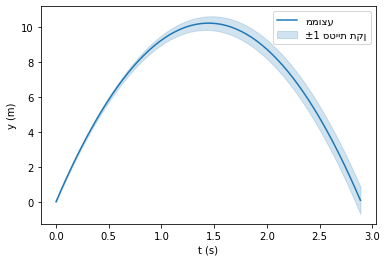

In [2]:
y_mean = Y.mean(axis=0)   # shape (60,) - ממוצע על פני הריצות, לכל זמן
y_std = Y.std(axis=0)     # shape (60,) - סטיית תקן על פני הריצות, לכל זמן

fig, ax = plt.subplots()
ax.plot(t, y_mean, color="tab:blue", label="ממוצע")
ax.fill_between(t, y_mean - y_std, y_mean + y_std, color="tab:blue", alpha=0.2, label="±1 סטיית תקן")
ax.set_xlabel("t (s)")
ax.set_ylabel("y (m)")
ax.legend()
plt.show()

### דוגמה: הגובה המרבי שכל ריצה הגיעה אליו

השאלה ההפוכה: לכל ריצה בנפרד, מהו הגובה המרבי לאורך הזמן שלה? כאן ציר הזמן הוא זה שנעלם — `axis=1`.

In [3]:
max_height_per_run = Y.max(axis=1)              # shape (5,) - גובה מרבי לכל ריצה
time_index_of_max = np.argmax(Y, axis=1)        # shape (5,) - איזה אינדקס זמן זה קרה

print("גובה מרבי בכל ריצה:", max_height_per_run)
print("אינדקס הזמן של השיא בכל ריצה:", time_index_of_max)

גובה מרבי בכל ריצה: [10.33162092 10.06863415 10.86571891 10.31000546  9.6638133 ]
אינדקס הזמן של השיא בכל ריצה: [30 29 30 30 29]


### באג נפוץ: לשכוח `axis`

בלי `axis=...`, פעולת הצמצום פועלת על **כל המערך יחד**, ומחזירה מספר בודד — לא וקטור. `()Y.mean` (בלי axis) מחזיר גובה ממוצע אחד, שמערבב זמנים מוקדמים (קרובים לקרקע) עם זמנים מאוחרים — תוצאה בלי שום פירוש פיזיקלי ברור.

In [4]:
scalar_mean = Y.mean()          # ממוצע על כל 300 הערכים ביחד - כמעט תמיד לא מה שרוצים
print(scalar_mean, type(scalar_mean))

6.72890619064453 <class 'numpy.float64'>


### נסו בעצמכם

חשבו את `y_sum_over_time`, סכום הגובה לאורך הזמן בכל ריצה בנפרד (איזה axis נעלם?), ואת `y_std_per_run`, סטיית התקן של הגובה בתוך כל ריצה.

In [5]:
# y_sum_over_time = Y.sum(axis=?)
# y_std_per_run = Y.std(axis=?)

`````{admonition} פתרון
:class: dropdown, tip
```python
y_sum_over_time = Y.sum(axis=1)     # axis=1 (זמן) נעלם -> shape (5,), אחד לכל ריצה
y_std_per_run = Y.std(axis=1)       # גם כאן axis=1 נעלם

print(y_sum_over_time.shape, y_std_per_run.shape)
```
`````

### בדקו את עצמכם

In [6]:
from jupyterquiz import display_quiz

questions = [
    {
        "question": "עבור <code>Y</code> בצורה <code>(5, 60)</code> (ריצה, זמן), מה מחזיר <code>Y.mean(axis=0)</code>?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "מספר בודד", "correct": False, "feedback": "לא — רק Y.mean() בלי axis מחזיר מספר בודד."},
            {"answer": "מערך בצורה (5,) - ממוצע על פני הזמן, לכל ריצה", "correct": False, "feedback": "זו התוצאה של axis=1, לא axis=0."},
            {"answer": "(5, 60) — אותה צורה, ללא שינוי", "correct": False, "feedback": "לא — axis=0 גורם לציר הריצות להיעלם מהתוצאה; הצורה קטנה מ-(5,60) ל-(60,)."},
            {"answer": "מערך בצורה (60,) - ממוצע על פני הריצות, לכל זמן", "correct": True, "feedback": "נכון — axis=0 (ציר הריצות) נעלם."}
        ]
    }
]
display_quiz(questions)

<IPython.core.display.Javascript object>

### תרגול עצמי

מצאו איזו ריצה הגיעה לגובה המרבי הכי גבוה מכל 5 הריצות, ובאיזה זמן זה קרה. (רמז: קודם `max_height_per_run`, ואז `np.argmax` עליו.)

In [7]:
# ...

`````{admonition} פתרון
:class: dropdown, tip
```python
max_height_per_run = Y.max(axis=1)
best_run = np.argmax(max_height_per_run)
best_time_index = np.argmax(Y[best_run])

print(f"הריצה הגבוהה ביותר: מספר {best_run}, בזמן t={t[best_time_index]:.2f}s")
```
`````